In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [3]:
train = pd.read_csv("/content/Train Split.csv")
test = pd.read_csv("/content/Test Split.csv")

In [5]:
print(train.shape)
print(test.shape)

(614, 13)
(367, 12)


In [6]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
train.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [9]:
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed'
]

for col in categorical_cols:
    train[col] = train[col].fillna(train[col].mode()[0])

In [10]:
numeric_missing_cols = [
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in numeric_missing_cols:
    train[col] = train[col].fillna(train[col].median())

In [11]:
train.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [12]:
# Loan_ID is an identifier and should not be used as a predictive feature
train.drop('Loan_ID', axis=1, inplace=True)

In [13]:
categorical_cols = train.select_dtypes(include='object').columns

categorical_cols

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [14]:
le = LabelEncoder()

for col in categorical_cols:
    train[col] = le.fit_transform(train[col])

In [15]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [16]:
X = train.drop('Loan_Status', axis=1)
y = train['Loan_Status']

In [17]:
print(X.shape)
print(y.shape)

(614, 11)
(614,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
print(X_train.shape)
print(X_test.shape)

(491, 11)
(123, 11)


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [23]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

In [24]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

In [36]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)
knn_prob = knn.predict_proba(X_test_scaled)[:, 1]

In [28]:
results = []

results.append([
    'Logistic Regression',
    accuracy_score(y_test, lr_pred),
    precision_score(y_test, lr_pred),
    recall_score(y_test, lr_pred),
    f1_score(y_test, lr_pred),
    roc_auc_score(y_test, lr_prob)
])

results.append([
    'Decision Tree',
    accuracy_score(y_test, dt_pred),
    precision_score(y_test, dt_pred),
    recall_score(y_test, dt_pred),
    f1_score(y_test, dt_pred),
    roc_auc_score(y_test, dt_prob)
])

results.append([
    'Random Forest',
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred),
    roc_auc_score(y_test, rf_prob)
])

results.append([
    'KNN',
    accuracy_score(y_test, knn_pred),
    precision_score(y_test, knn_pred),
    recall_score(y_test, knn_pred),
    f1_score(y_test, knn_pred),
    roc_auc_score(y_test, knn_prob)
])

In [29]:
metrics_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'ROC-AUC'
    ]
)

metrics_df.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.862,0.840,0.988,0.908,0.802
1,Decision Tree,0.821,0.825,0.941,0.879,0.726
2,Random Forest,0.837,0.849,0.929,0.888,0.793
3,KNN,0.846,0.837,0.965,0.896,0.779


In [30]:
metrics_df.sort_values(
    by='F1-score',
    ascending=False
).round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.862,0.840,0.988,0.908,0.802
3,KNN,0.846,0.837,0.965,0.896,0.779
2,Random Forest,0.837,0.849,0.929,0.888,0.793
1,Decision Tree,0.821,0.825,0.941,0.879,0.726


In [31]:
best_row = metrics_df.loc[
    metrics_df['F1-score'].idxmax()
]

print(best_row)

Model        Logistic Regression
Accuracy                0.861789
Precision                   0.84
Recall                  0.988235
F1-score                0.908108
ROC-AUC                 0.801858
Name: 0, dtype: object


In [32]:
best_model_name = best_row['Model']

print("Best model:", best_model_name)

Best model: Logistic Regression


In [33]:
if best_model_name == 'Logistic Regression':
    best_pred = lr_pred

elif best_model_name == 'Decision Tree':
    best_pred = dt_pred

elif best_model_name == 'Random Forest':
    best_pred = rf_pred

else:
    best_pred = knn_pred

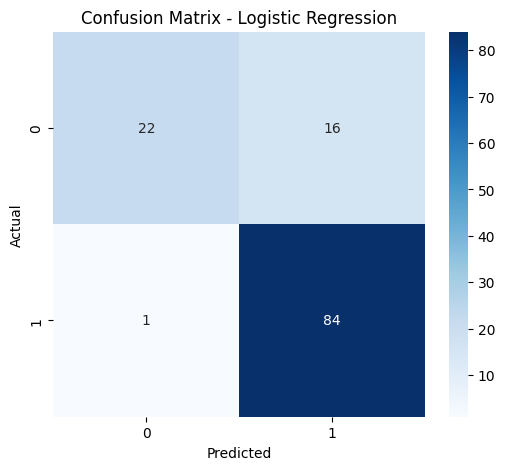

In [34]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - ' + best_model_name)
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [35]:
print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



After running the code, the actual winning model name:

I selected **logistic regression** because it achieved the highest F1-score while maintaining strong accuracy, precision, and recall. The confusion matrix also showed that the model correctly classified most loan applications with relatively few errors. ROC-AUC was considered as an additional measure of how well the model separated approved and non-approved loans.